# Imports

In [ ]:
import sys
from pathlib import Path
HOME = Path(r"D:\Workspace\Repository\skripsi\submodules\object-detection-engine")
DATA = HOME / "data"
MODELS  = HOME / "models"
sys.path.append(str(MODELS))

import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection 
from models.scold.model import LVL
from transformers import RobertaTokenizer

# Config

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FIGURE_SIZE = (8, 6)

# Data Loading

## Image Loading

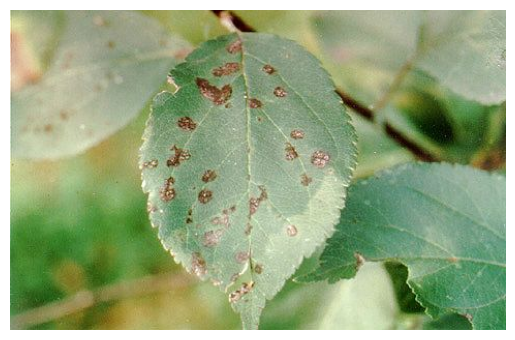

In [3]:
IMAGE = f"{DATA}/applescab.jpg"
image = Image.open(IMAGE).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

## Model Loading

### Grounding Dino


In [4]:
model_id = "IDEA-Research/grounding-dino-base"
gdino_processor = AutoProcessor.from_pretrained(model_id)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(DEVICE)

### CLIP

In [5]:
# Load model
scold_model = LVL()
scold_model.load_state_dict(torch.load(f"{MODELS}/scold/scold.pt", map_location=DEVICE))
scold_model.to(DEVICE)
scold_model.eval()

scold_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
scold_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Andakara\AppData\Local\Temp\ipykernel_41580\1488164452.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_

# Extracting Candidate Regions

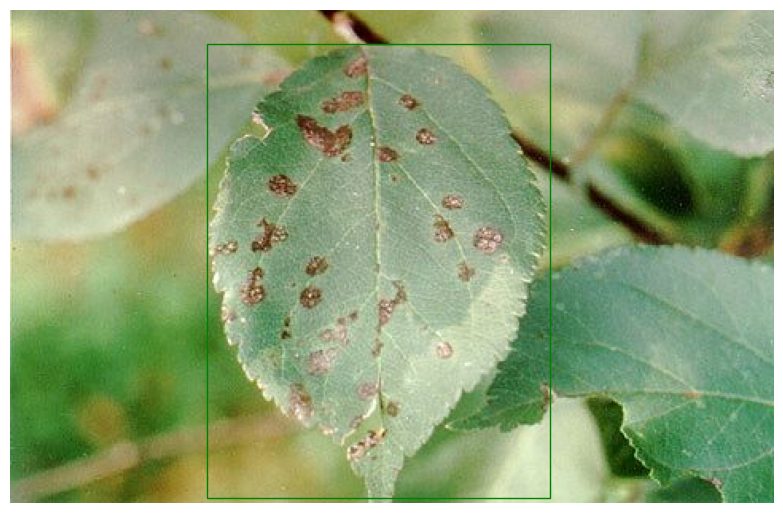

In [6]:
def get_candidate_boxes(image, labels, model, processor, device=DEVICE, box_threshold=0.35, text_threshold=0.25):
    text = " . ".join(labels) + "."
    inputs = processor(images=image, text=text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=box_threshold,
        text_threshold=text_threshold,
        target_sizes=[image.size[::-1]]
    )
    
    return results[0]['boxes'].cpu()

all_labels = ['diseased leaf']
candidate_boxes = get_candidate_boxes(image, all_labels, gdino_model, gdino_processor)

# Visualize the candidate boxes from Grounding DINO
def plot_image_with_boxes(image, boxes, labels=None, figsize=FIGURE_SIZE):
    fig, ax = plt.subplots(1, figsize=figsize)
    
    ax.imshow(image)
    
    for i, box in enumerate(boxes):
        if box is None:
            continue
        x_min, y_min, x_max, y_max = box
        rect = plt.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=1,
            edgecolor="green",
            facecolor="none",
        )
        ax.add_patch(rect)

        if labels is not None and labels[i] is not None:
            label_size = len(labels[i]) * 10
            ax.text(
                x_min + (x_max - x_min) / 2 - label_size / 2,
                y_min - 10,
                labels[i],
                fontsize=12,
                verticalalignment="top",
                color="white",
                bbox=dict(facecolor="green", alpha=0.5, edgecolor="none"),
            )

    plt.tight_layout(pad=0)
    plt.axis('off')
    plt.show()

plot_image_with_boxes(image, candidate_boxes)

# Labels and Image Embeddings

In [7]:
from qdrant_client import QdrantClient
from qdrant_client.http import models
from tqdm.auto import tqdm
import io
import pandas as pd

In [8]:
df = pd.read_parquet(f"{DATA}/leafnet/leafnet_sampled.parquet")
print(df.head())

                                         file_name  \
0  D:/AI/Dataset/dataset/dataset/079628_PH0119.png   
1  D:/AI/Dataset/dataset/dataset/079551_PH0035.png   
2  D:/AI/Dataset/dataset/dataset/079634_PH0053.png   
3  D:/AI/Dataset/dataset/dataset/079542_PH0307.png   
4  D:/AI/Dataset/dataset/dataset/079536_PH0325.png   

                                               image  \
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...   

                                             caption                label  
0  a image of Black Pepper healthy leaves with le...  BlackPepper_Healthy  
1  a image of Black Pepper healthy leaves with le...  BlackPepper_Healthy  
2  a image of Black Pepper healthy leaves with le...  BlackPepper_Healthy  
3  a image of Black Pepper healthy

In [9]:
print(df['caption'].unique())

<StringArray>
[                                                                                                                                                                                         'a image of Black Pepper healthy leaves with leaves appearing normal and healthy',
                                                                                                                'a image of Black Pepper leaves diseased by yellow mottle virus with symptoms of chlorotic, mottled, vein-cleared, and distorted leaves and stunted growth',
                                                                                                                                                    'a image of Cucumber leaves diseased by Downy Mildew with symptoms of yellow to pale green spots and velvety grey fuzz',
 'a image of Maize leaves diseased by Cercospora leaf spot Gray leaf spot with symptoms of small necrotic spots with halos expanding into rectangular gray to brown lesions, typica

In [10]:
# Encoding functions
def encode_text(texts):
    inputs = scold_tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
    with torch.no_grad():
        # Call text encoder directly instead of going through forward method
        text_emb = scold_model.get_texts_feature(inputs["input_ids"], inputs["attention_mask"])
    return text_emb.cpu().numpy()

def encode_image_from_bytes(image_bytes):
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    image_tensor = scold_transform(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        # Call image encoder directly instead of going through forward method
        image_emb = scold_model.get_images_features(image_tensor)
    return image_emb.cpu().numpy()

In [11]:
# Initialize Qdrant client
client = QdrantClient(url="http://localhost:6333")
collection_name = "leaf_disease_collection"

In [12]:
if client.collection_exists(collection_name):
    client.delete_collection(collection_name)
    
client.create_collection(
    collection_name=collection_name,
    vectors_config={
        "text": models.VectorParams(size=512, distance=models.Distance.COSINE),
        "image": models.VectorParams(size=512, distance=models.Distance.COSINE),
    }
)

True

In [13]:
batch_size = 10  
total_points = []

for i in tqdm(range(0, len(df), batch_size)):
    batch_df = df.iloc[i:i+batch_size]
    batch_points = []
    
    for idx, row in batch_df.iterrows():
        caption_text = str(row['caption'])

        text_vec = encode_text([caption_text])[0]
    
        img_vec = encode_image_from_bytes(row['image']['bytes'])[0]
        
        batch_points.append(models.PointStruct(
            id=idx,
            vector={
                "text": text_vec.tolist(),
                "image": img_vec.tolist(),
            },
            payload={
                "caption": caption_text,
                "label": row['label'],
                "source_id": idx
            }
        ))
        
        total_points.extend(batch_points)
    try:
        client.upsert(
            collection_name=collection_name,
            points=batch_points
        )
    except Exception as e:
        tqdm.write(f"Batch {i//batch_size + 1} error: {e}")
        continue

  0%|          | 0/45 [00:00<?, ?it/s]

In [14]:
def cross_modal_search(query_text=None, image_bytes=None, limit=5):
    if query_text is not None:
        query_vector = encode_text([query_text])[0].tolist()
        search_result = client.query_points(
            collection_name="leaf_disease_collection",
            query=query_vector,
            using="text",
            limit=limit,
            with_payload=True
        )
    elif image_bytes is not None:
        query_vector = encode_image_from_bytes(image_bytes)[0].tolist()
        search_result = client.query_points(
            collection_name="leaf_disease_collection",
            query=query_vector,
            using="image",
            limit=limit,
            with_payload=True
        )
    else:
        raise ValueError("Either query_text or image_bytes must be provided")
    
    return search_result

## Retrieval testing

In [15]:
def image_path_to_bytes(image_path):
    
    with open(image_path, 'rb') as f:
        image_bytes = f.read()
    
    return image_bytes


image_query_path = f"{DATA}/applescab.jpg"  
image_bytes = image_path_to_bytes(image_query_path)
image_results = cross_modal_search(image_bytes=image_bytes, limit=1)

print("Image-to-Image Search Results:")
print("=" * 50)
for i, result in enumerate(image_results.points, 1):
    print(f"{i}. Score: {result.score:.4f}")
    print(f"   Caption: {result.payload['caption']}")
    print(f"   Label: {result.payload['label']}")
    print(f"   Source ID: {result.payload['source_id']}")
    print()


Image-to-Image Search Results:
1. Score: 0.7316
   Caption: a image of Apple leaves diseased by Scab with symptoms of olive-green to dark brown spots on leaves, leading to yellowing
   Label: Apple_Scab
   Source ID: 375



In [16]:
image_results.points

[ScoredPoint(id=375, version=37, score=0.7316402, payload={'caption': 'a image of Apple leaves diseased by Scab with symptoms of olive-green to dark brown spots on leaves, leading to yellowing', 'label': 'Apple_Scab', 'source_id': 375}, vector=None, shard_key=None, order_value=None)]

# Object Detection


COMPARING THREE ENSEMBLE METHODS

Method 1: Mean Score per Label

Detection 1:
  Predicted Label: Apple_CedarAppleRust
  Confidence: 0.6878
  Label Scores: {'Apple_CedarAppleRust': np.float64(0.6878173), 'Apple_Scab': np.float64(0.6670570975)}
  Top-5 Results:
    1. Apple_CedarAppleRust: 0.6878
    2. Apple_Scab: 0.6821
    3. Apple_Scab: 0.6677
    4. Apple_Scab: 0.6623
    5. Apple_Scab: 0.6561

Method 2: Weighted Voting (Sum of Scores)

Detection 1:
  Predicted Label: Apple_Scab
  Confidence: 0.7951
  Label Scores: {'Apple_CedarAppleRust': 0.6878173, 'Apple_Scab': 2.66822839}
  Top-5 Results:
    1. Apple_CedarAppleRust: 0.6878
    2. Apple_Scab: 0.6821
    3. Apple_Scab: 0.6677
    4. Apple_Scab: 0.6623
    5. Apple_Scab: 0.6561

Method 3: Reciprocal Rank Fusion

Detection 1:
  Predicted Label: Apple_Scab
  Confidence: 0.0420
  Label Scores: {'Apple_CedarAppleRust': 0.01127569344262295, 'Apple_Scab': 0.04204278317338463}
  Top-5 Results:
    1. Apple_CedarAppleRust: 0.6878
    2. 

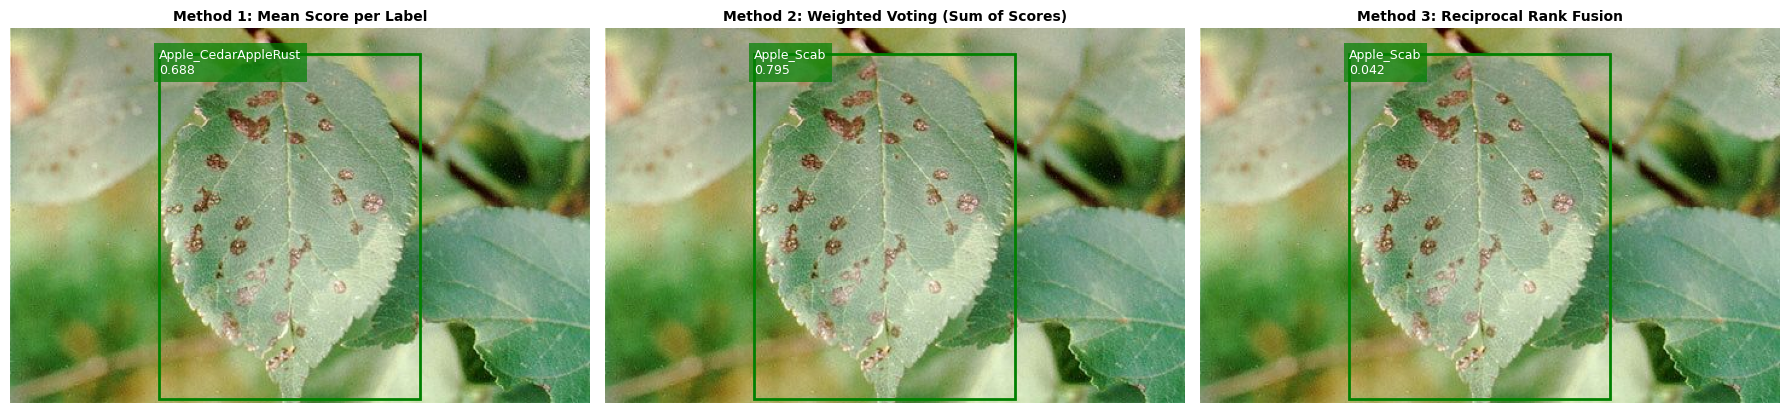


SUMMARY COMPARISON

Method 1: Mean Score per Label:
  Predicted: Apple_CedarAppleRust
  Confidence: 0.6878

Method 2: Weighted Voting (Sum of Scores):
  Predicted: Apple_Scab
  Confidence: 0.7951

Method 3: Reciprocal Rank Fusion:
  Predicted: Apple_Scab
  Confidence: 0.0420


In [ ]:
import numpy as np
from collections import Counter

# def detect_and_classify_method1_mean_score(image, candidate_boxes, top_k=5):
#     """Method 1: Mean Score per Label"""
#     tensor_transform = transforms.ToTensor()
#     image_pt = tensor_transform(image)
#     height, width = image_pt.shape[-2:]
    
#     results = []
    
#     for box_idx, box in enumerate(candidate_boxes):
#         x_min, y_min, x_max, y_max = map(int, box)
#         x_max, y_max = min(width, x_max), min(height, y_max)

#         if x_min > x_max or x_min > width or y_min > y_max or y_min > height:
#             continue

#         cropped_image = image_pt[:, y_min:y_max+1, x_min:x_max+1]
#         if not torch.prod(torch.tensor(cropped_image.shape)):
#             continue

#         cropped_pil = transforms.functional.to_pil_image(cropped_image)
#         buffer = io.BytesIO()
#         cropped_pil.save(buffer, format='PNG')
#         cropped_bytes = buffer.getvalue()
        
#         search_results = cross_modal_search(image_bytes=cropped_bytes, limit=top_k)
        
#         labels = [result.payload['label'] for result in search_results.points]
#         scores = [result.score for result in search_results.points]
        
#         # Method 1: Average score per label
#         label_votes = {}
#         for label, score in zip(labels, scores):
#             if label not in label_votes:
#                 label_votes[label] = []
#             label_votes[label].append(score)
        
#         label_scores = {label: np.mean(scores) for label, scores in label_votes.items()}
#         final_label = max(label_scores.items(), key=lambda x: x[1])
        
#         results.append({
#             'box': box,
#             'predicted_label': final_label[0],
#             'confidence': final_label[1],
#             'method': 'Mean Score',
#             'label_scores': label_scores,
#             'top_k_results': list(zip(labels, scores))
#         })
    
#     return results


def detect_and_classify_method2_weighted_vote(image, candidate_boxes, top_k=5):
    """Method 2: Weighted Voting (score as weight)"""
    tensor_transform = transforms.ToTensor()
    image_pt = tensor_transform(image)
    height, width = image_pt.shape[-2:]
    
    results = []
    
    for box_idx, box in enumerate(candidate_boxes):
        x_min, y_min, x_max, y_max = map(int, box)
        x_max, y_max = min(width, x_max), min(height, y_max)

        if x_min > x_max or x_min > width or y_min > y_max or y_min > height:
            continue

        cropped_image = image_pt[:, y_min:y_max+1, x_min:x_max+1]
        if not torch.prod(torch.tensor(cropped_image.shape)):
            continue

        cropped_pil = transforms.functional.to_pil_image(cropped_image)
        buffer = io.BytesIO()
        cropped_pil.save(buffer, format='PNG')
        cropped_bytes = buffer.getvalue()
        
        search_results = cross_modal_search(image_bytes=cropped_bytes, limit=top_k)
        
        labels = [result.payload['label'] for result in search_results.points]
        scores = [result.score for result in search_results.points]
        
        # Method 2: Sum of scores (weighted voting)
        label_votes = {}
        for label, score in zip(labels, scores):
            if label not in label_votes:
                label_votes[label] = 0
            label_votes[label] += score
        
        final_label = max(label_votes.items(), key=lambda x: x[1])
        
        # Normalize confidence
        total_score = sum(label_votes.values())
        confidence = final_label[1] / total_score if total_score > 0 else 0
        
        results.append({
            'box': box,
            'predicted_label': final_label[0],
            'confidence': confidence,
            'method': 'Weighted Vote',
            'label_scores': label_votes,
            'top_k_results': list(zip(labels, scores))
        })
    
    return results


# def detect_and_classify_method3_rank_fusion(image, candidate_boxes, top_k=5):
#     """Method 3: Reciprocal Rank Fusion (position-based)"""
#     tensor_transform = transforms.ToTensor()
#     image_pt = tensor_transform(image)
#     height, width = image_pt.shape[-2:]
    
#     results = []
    
#     for box_idx, box in enumerate(candidate_boxes):
#         x_min, y_min, x_max, y_max = map(int, box)
#         x_max, y_max = min(width, x_max), min(height, y_max)

#         if x_min > x_max or x_min > width or y_min > y_max or y_min > height:
#             continue

#         cropped_image = image_pt[:, y_min:y_max+1, x_min:x_max+1]
#         if not torch.prod(torch.tensor(cropped_image.shape)):
#             continue

#         cropped_pil = transforms.functional.to_pil_image(cropped_image)
#         buffer = io.BytesIO()
#         cropped_pil.save(buffer, format='PNG')
#         cropped_bytes = buffer.getvalue()
        
#         search_results = cross_modal_search(image_bytes=cropped_bytes, limit=top_k)
        
#         labels = [result.payload['label'] for result in search_results.points]
#         scores = [result.score for result in search_results.points]
        
#         # Method 3: Reciprocal Rank Fusion
#         # RRF(d) = Σ 1/(k + rank(d))
#         k = 60  # constant, typically 60
#         label_votes = {}
#         for rank, (label, score) in enumerate(zip(labels, scores), start=1):
#             if label not in label_votes:
#                 label_votes[label] = 0
#             # Combine RRF with similarity score
#             rrf_score = 1.0 / (k + rank)
#             label_votes[label] += rrf_score * score
        
#         final_label = max(label_votes.items(), key=lambda x: x[1])
        
#         results.append({
#             'box': box,
#             'predicted_label': final_label[0],
#             'confidence': final_label[1],
#             'method': 'Rank Fusion',
#             'label_scores': label_votes,
#             'top_k_results': list(zip(labels, scores))
#         })
    
#     return results


# Run all three methods
print("="*80)
print("COMPARING THREE ENSEMBLE METHODS")
print("="*80)

methods = [
    # ("Method 1: Mean Score per Label", detect_and_classify_method1_mean_score),
    ("Method 2: Weighted Voting (Sum of Scores)", detect_and_classify_method2_weighted_vote),
    # ("Method 3: Reciprocal Rank Fusion", detect_and_classify_method3_rank_fusion)
]

all_results = {}

for method_name, method_func in methods:
    print(f"\n{'='*80}")
    print(f"{method_name}")
    print('='*80)
    
    results = method_func(image, candidate_boxes, top_k=5)
    all_results[method_name] = results
    
    for i, result in enumerate(results, 1):
        print(f"\nDetection {i}:")
        print(f"  Predicted Label: {result['predicted_label']}")
        print(f"  Confidence: {result['confidence']:.4f}")
        print(f"  Label Scores: {result['label_scores']}")
        print(f"  Top-5 Results:")
        for j, (label, score) in enumerate(result['top_k_results'], 1):
            print(f"    {j}. {label}: {score:.4f}")

# Visualization comparison
def visualize_method_comparison(image, all_results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, (method_name, results) in enumerate(all_results.items()):
        ax = axes[idx]
        ax.imshow(image)
        ax.set_title(method_name, fontsize=10, fontweight='bold')
        
        for result in results:
            box = result['box']
            label = result['predicted_label']
            conf = result['confidence']
            
            x_min, y_min, x_max, y_max = box
            rect = plt.Rectangle(
                (x_min, y_min),
                x_max - x_min,
                y_max - y_min,
                linewidth=2,
                edgecolor="green",
                facecolor="none",
            )
            ax.add_patch(rect)
            
            label_text = f"{label}\n{conf:.3f}"
            ax.text(
                x_min,
                y_min - 5,
                label_text,
                fontsize=9,
                verticalalignment="top",
                color="white",
                bbox=dict(facecolor="green", alpha=0.7, edgecolor="none"),
            )
        
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_method_comparison(image, all_results)

# Summary comparison
print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80)
for method_name, results in all_results.items():
    if results:
        print(f"\n{method_name}:")
        print(f"  Predicted: {results[0]['predicted_label']}")
        print(f"  Confidence: {results[0]['confidence']:.4f}")